<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/DeepLearning_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import nltk
import string
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('punkt_path')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Error loading punkt_path: Package 'punkt_path' not found
[nltk_data]     in index
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df = pd.read_json("/content/News_Category_Dataset_v3.json.zip", lines=True)

df = df[['headline','short_description','category']]
df.dropna(inplace=True)

df['text'] = df['headline'] + " " + df['short_description']


In [ ]:
df.head()

,headline,short_description,category,text
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",PARENTING,The Funniest Tweets From Parents This Week (Se...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...


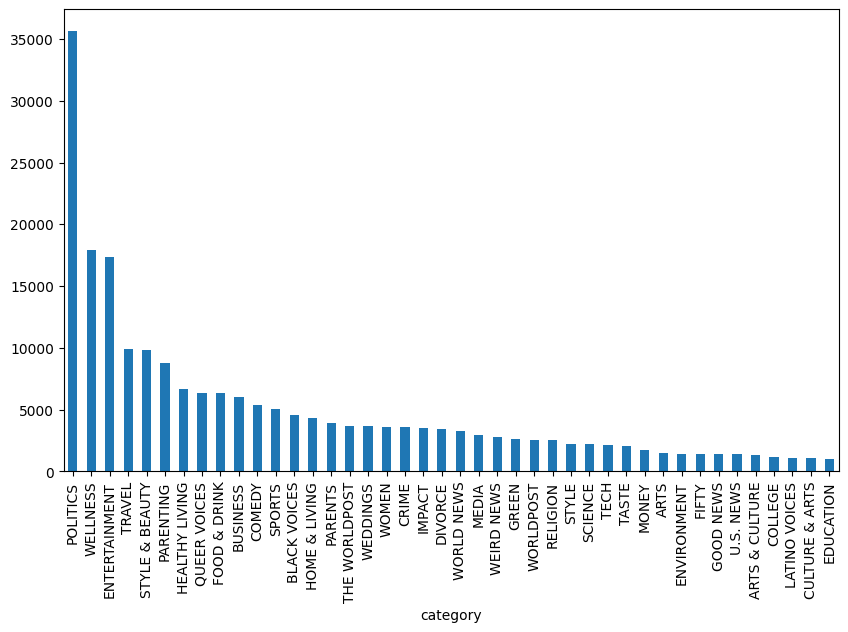

In [ ]:
plt.figure(figsize=(10,6))
df['category'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess(text):
  text = text.lower()
  text = re.sub('<.*?>','',text)
  text = re.sub('[^a-zA-Z]','',text)
  text = re.sub('http\S+','',text)
  tokens = word_tokenize(text)
  tokens = [w for w in tokens if w not in stop_words]
  tokens = [lemmatizer.lemmatize(w) for w in tokens]

  return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-1707813948.py:9: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('http\S+','',text)


In [ ]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
freq = Counter(all_words).most_common(20)
freq_df = pd.DataFrame(freq,columns=['Word','Freq'])

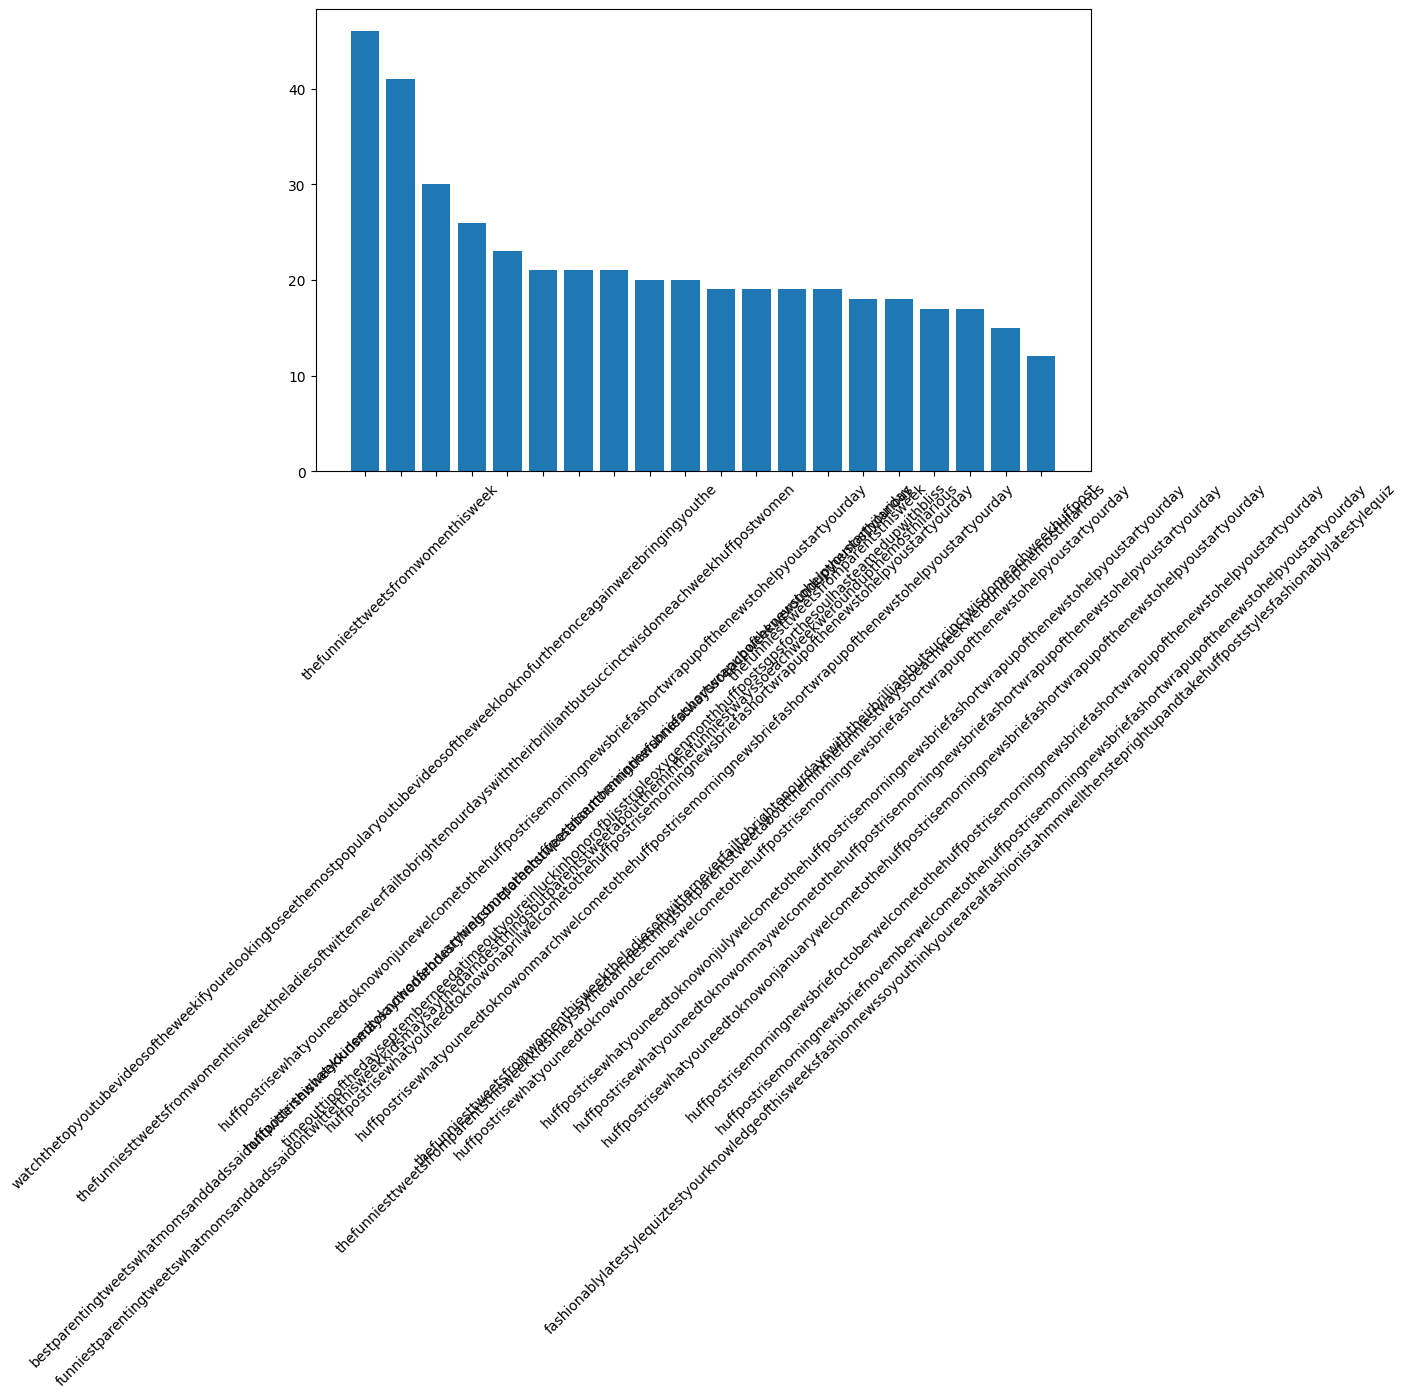

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(freq_df['Word'],freq_df['Freq'])
plt.xticks(rotation=45)
plt.show()

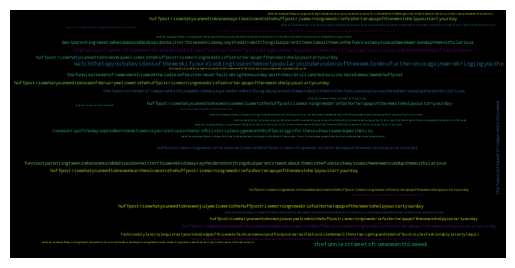

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(width=800,height=400).generate(" ".join(all_words))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [ ]:
fig = px.scatter_3d(
    freq_df,
    x='Word',
    y='Freq',
    z='Freq',
    color='Freq',
    size='Freq',
)

fig.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

In [ ]:
df.head()

,headline,short_description,category,text,clean_text,label
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...,overmillionamericansrollupsleevesforomicrontar...,35
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li...",americanairlinesflyerchargedbannedforlifeafter...,35
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,ofthefunniesttweetsaboutcatsanddogsthisweeksep...,5
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",PARENTING,The Funniest Tweets From Parents This Week (Se...,thefunniesttweetsfromparentsthisweekseptaccide...,22
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...,womanwhocalledcopsonblackbirdwatcherloseslawsu...,35


In [ ]:
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['clean_text'])

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(df['clean_text'])

seq = tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(seq,maxlen=200)
y=df['label']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pad,y, test_size=0.2,random_state=42)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Embedding(20000, 128, input_length=200),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(len(le.classes_),activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.fit(X_train, y_train, epochs=5, validation_data=(X_test,y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Epoch 1/5
5239/5239 ━━━━━━━━━━━━━━━━━━━━ 2020s 384ms/step - accuracy: 0.1673 - loss: 3.2700 - val_accuracy: 0.1707 - val_loss: 3.2151
Epoch 2/5
5239/5239 ━━━━━━━━━━━━━━━━━━━━ 2018s 376ms/step - accuracy: 0.1736 - loss: 3.1651 - val_accuracy: 0.1574 - val_loss: 3.2421
Epoch 3/5
2585/5239 ━━━━━━━━━━━━━━━━━━━━ 15:30 351ms/step - accuracy: 0.1908 - loss: 3.1096

KeyboardInterrupt: 